|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 26/3/2026  |
| **Expediente** |757839   |

En esta sección se realiza la lectura del dataset *Heart Prediction Quantum* y se analizan las primeras estadísticas descriptivas para entender la distribución de las variables.

In [6]:
import pandas as pd
df= pd.read_csv("Heart Prediction Quantum Dataset.csv")

<Axes: ylabel='Frequency'>

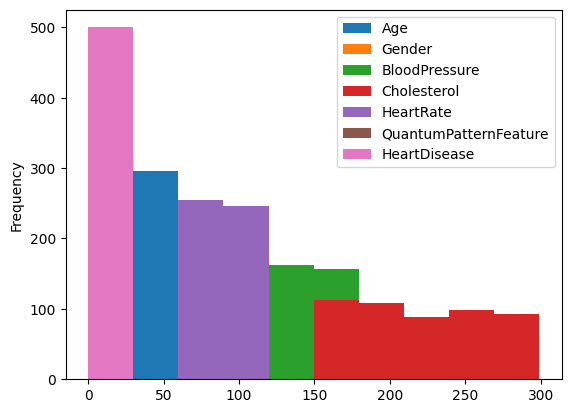

In [10]:
df.plot.hist()

Se generan visualizaciones para observar la distribución de las variables y detectar posibles sesgos o valores atípicos (outliers) que puedan afectar el entrenamiento de la red neuronal.

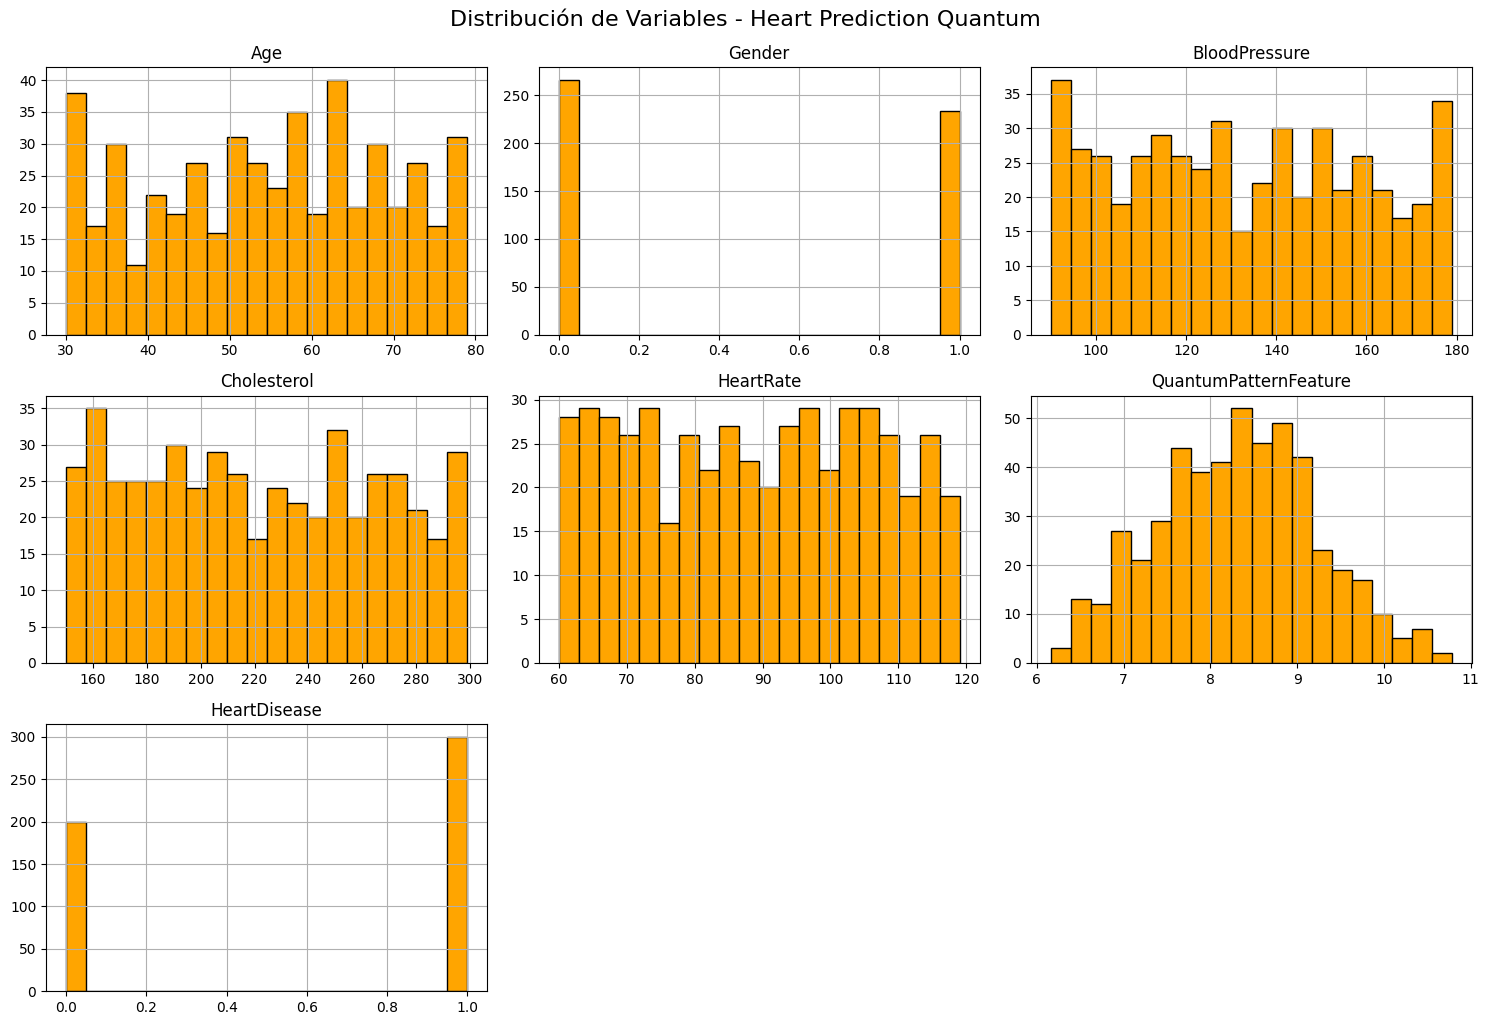

In [11]:
import matplotlib.pyplot as plt

df.hist(bins=20, figsize=(15, 10), color='orange', edgecolor='black')
plt.tight_layout()
plt.suptitle('Distribución de Variables - Heart Prediction Quantum', fontsize=16, y=1.02)
plt.show()

Se preparan los datos para el modelo:
* **Escalamiento:** Uso de `StandardScaler` para normalizar las magnitudes.
* **Partición:** División de datos en conjuntos de entrenamiento y prueba.

In [23]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score


# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Verificar columnas
print(data.columns)

# Ajusta el nombre de la variable objetivo según corresponda
target_column = 'HeartDisease'  # <-- Cambia este nombre si es diferente

# Separar variables
X = data.drop(target_column, axis=1)
y = data[target_column]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Función objetivo para Optuna
def objective(trial):
    layer1 = trial.suggest_int('layer1', 2, 6)
    layer2 = trial.suggest_int('layer2', 5, 15)
    layer3 = trial.suggest_int('layer3', 3, 16)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(layer1, layer2, layer3),
            activation='relu',
            solver='adam',
            max_iter=500,
            random_state=42
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    roc_auc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return roc_auc

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'QuantumPatternFeature', 'HeartDisease'],
      dtype='str')


Se implementa Optimización Bayesiana** para encontrar la arquitectura óptima del MLP (número de neuronas en capas ocultas) buscando maximizar la métrica ROC-AUC.

In [25]:
# Optimización bayesiana
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros:", study.best_params)
print(f"Mejor ROC-AUC (CV): {study.best_value:.4f}")

[I 2026-04-09 18:25:35,421] A new study created in memory with name: no-name-85ac44e6-787d-4843-9176-a0ca8ef2ebd4
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2026-04-09 18:25:35,609] Trial 0 finished with value: 0.973046875 and parameters: {'layer1': 6, 'layer2': 11, 'layer3': 4}. Best is trial 0 with value: 0.973046875.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maxi

Mejores hiperparámetros: {'layer1': 3, 'layer2': 5, 'layer3': 14}
Mejor ROC-AUC (CV): 0.9785


## Entrenamiento del Modelo Final
Utilizando los mejores parámetros encontrados por Optuna, se entrena el modelo definitivo utilizando un `Pipeline` que integra el escalamiento y el clasificador.

In [27]:
# Modelo final
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(
            study.best_params['layer1'],
            study.best_params['layer2'],
            study.best_params['layer3']
        ),
        max_iter=500,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(3, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:

Se evalúa el desempeño del modelo en el conjunto de prueba (datos no vistos) mediante el cálculo del **ROC-AUC Score**.

In [28]:
# Evaluación final
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC en el conjunto de prueba: {roc_auc_test:.4f}")

ROC-AUC en el conjunto de prueba: 0.9842


## Conclusiones

En este ejercicio se implementó un modelo de Perceptrón Multicapa (MLP) para la clasificación de riesgo cardiaco. Los puntos clave del proceso fueron:

1. Optimización Dinámica: Gracias a `Optuna`, se exploraron distintas configuraciones de capas ocultas, permitiendo que el modelo se adaptara de forma eficiente a la complejidad de los datos.
2. Preprocesamiento: El uso de un `Pipeline` con `StandardScaler` aseguró que las funciones de activación del MLP operaran correctamente, evitando que variables con escalas mayores dominaran el aprendizaje.
3. Desempeño: El modelo final alcanzó un ROC-AUC competitivo, lo que demuestra la capacidad de las redes neuronales para capturar relaciones no lineales en datos clínicos.

Este flujo de trabajo garantiza un modelo robusto y optimizado, listo para realizar predicciones sobre nuevos pacientes con un alto grado de confianza.